# Count map from $m_5$ N trialss

In [1]:
import numpy as np
import dask.array as da
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import healpy as hp
import matplotlib.pyplot as plt
from ulid import ULID
import fitsio

from simulMap import *
from fitMap import *
from lumMag_sampling import *
from mappers import DepthMapper, CountMapper
from spectra import Spectrum

# Set random seed for reproducibility
#np.random.seed(42)

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

Number of pixels = 49152


## Bolometric data generation

They will be saved in a .fits file to be reused later. Band data will be deduced from bolometric one in order to be sure to aways work with the same mock catalog.

In [3]:
NSource_px_th = int(1e6)
Ntrial = int(1e2)
dataNlist, data_IDs = [], []
for i in range(Ntrial):
    if i % 10 == 0: print(f'i = {i}', end = '\t')
    dataN = generate_lumMag(NSource_px_th, to_table=False, L_min=1e7, L_bandRatio=1, verbose=False) #create bolometric data to convert in each band drom it.
    data_id = ULID()
    dataNlist.append(dataN)
    data_IDs.append(data_id)

print("\nGeneration complete.")

i = 0	i = 10	i = 20	i = 30	i = 40	i = 50	i = 60	i = 70	i = 80	i = 90	
Generation complete.


In [4]:
dfRatio = {'Ratio_ID': np.array(data_IDs, dtype='S26'), 'Ratio_Cat': np.array(dataNlist)} #"Cat" for "Catalog"

output_path = "Catalog_m5/Catalog_m5Ratio/"
sufix = "testRatio"
outputfile = output_path + sufix + '.fits'

header_global = {'MAP_TYPE': 'Ratio_Catalog'}
BAND = 'BOLOMETRIC'

with fitsio.FITS(outputfile, 'rw', clobber=True) as fits: #Ouvrir le fichier en mode écriture ('rw' crée ou écrase)
        
    # Ajouter une PrimaryHDU avec des métadonnées globales
    fits.write(None, header=header_global) # None car la Primary est vide de données
    
    # Ajouter le premier DataFrame (Extension 1)
    # extname donne un nom à l'HDU pour s'y retrouver
    fits.write(dfRatio, extname=BAND)

    header = fits[BAND]
    # On les trie (INDEX_0, INDEX_1, ...) pour respecter l'ordre des colonnes
    header.write_key("INDEX_0", "z", comment="Redshift")
    header.write_key("INDEX_1", "dL", comment="Luminosity distance (Mpc)")
    header.write_key("INDEX_2", "L", comment="Luminosity (solLum)")
    header.write_key("INDEX_3", "M", comment="Absolute Magnitude")
    header.write_key("INDEX_4", "m", comment="Apparent Magnitude")

print("Saving complete.")

Saving complete.


## Reference spectrum

SED bolometric integral : -4469521748671.2


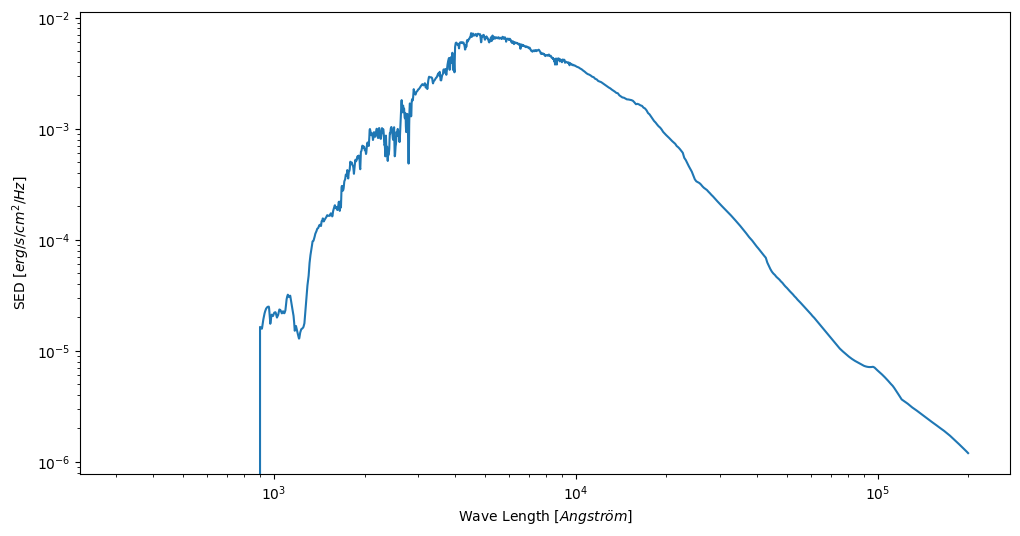

In [3]:
DIR_SED = "../data/data SED/SED GAL/COSMOS/"
FILE_SED = "Ell1_A_0"
file = DIR_SED + FILE_SED + ".sed"
refSpectum = Spectrum.read_sed(file)
refSpectum.plot(loglog=True, title="")

output_path = "../Figures/SED_Figures/SED_Galaxies/"
#get_savefig(plt, output_path, "SED_Gal")

integral = refSpectum.integrate()
print(f"SED bolometric integral : {integral}")

Saving SED_Response in ../Figures/SED_Figures/SED_Galaxies/SED_Response.pdf


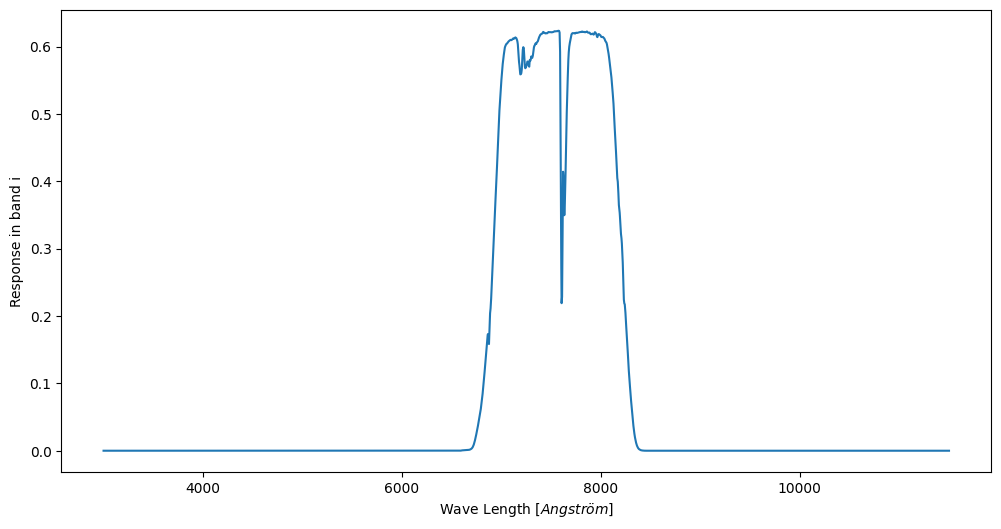

In [4]:
band = 'i'
file_band = f"../data/data LSST/total_{band}.dat"
responseSpectrum = Spectrum.read_sed(file_band, yname=f"Response in band {band}", yunit="")
responseSpectrum.wavelength = responseSpectrum.wavelength*10
responseSpectrum.plot(loglog=False, title="")

output_path = "../Figures/SED_Figures/SED_Galaxies/"
get_savefig(plt, output_path, "SED_Response")

In [5]:
_, response = refSpectum.get_surrounding(responseSpectrum)
response = response.mean(axis=0)
L_bandRatio = refSpectum.ratio_integrate(response)
print(f"SED band {band} ratio : {L_bandRatio}")

SED band i ratio : 0.045453330734618005


## Reading bolometric data file

In [7]:
DIR = "Catalog_m5/Catalog_m5Ratio/"
sufix = "testRatio"
outputfile = DIR + sufix + '.fits'

dataN, data_ID = read_lumMag_fits(outputfile, 0, L_bandRatio=L_bandRatio, to_band=band)
dataN

z,dL,L,M,m,L_i,M_i,m_i
,Mpc,solLum,,,solLum,solLum,solLum
float64,float64,float64,float64,float64,float64,float64,float64
1.014542326432987,7027.145682378759,30645546.713645894,-13.885918433823983,30.34797635193339,1392942.1703185327,-10.529832716341879,33.70406206941549
0.7363209110631574,4734.488512540824,2677336894.761015,-18.73925755696431,24.63710777876085,121693879.36556758,-15.383171839482204,27.99319349624296
0.8083768640688359,5309.647095345624,25510623.16818487,-13.686802668986099,29.938525614728903,1159542.7921097155,-10.330716951503994,33.294611332211005
0.45044390448429966,2612.4876463369646,15778842.982701296,-13.165187886180528,28.920083341203785,717200.9687023285,-9.809102168698423,32.276169058685895
0.4987659532367315,2950.87540205728,12663883.576797798,-12.926417273155431,29.423337087896755,575615.6886008875,-9.570331555673327,32.77942280537886
0.8516695348807279,5661.8510749809375,125990258.58744024,-15.42084241824489,28.34394979089506,5726676.892914968,-12.064756700762784,31.700035508377162
0.8438439425794242,5597.832695085243,794616713.3066007,-17.42039423851022,26.319705333348903,36117976.27718006,-14.064308521028112,29.67579105083101
0.32696617180733534,1792.138316712811,169180714.42846972,-15.740877136493586,25.5259804902122,7689826.9668361945,-12.384791419011483,28.8820662076943
